# Parkinson's Disease Gene Expression Analysis
## Notebook 4: PCA

Dataset: GSE99039 (GEO)

Flow of this notebook:
- Load Load the preprocessed data
- Apply PCA
- Visualize PCA in 2D
- Save the PCA output

Author: Athanasiadou Maria

## Step 1 - Load the preprocessed data
The clean dataset saved at the end of Notebook 03 contains only the high-variance genes, properly scaled, with labels attached.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [4]:
# Load the preprocessed data
data = pd.read_csv("../data/preprocessed_expression.csv.gz", index_col=0, compression="gzip")

print(f"Data loaded successfully.")
print(f"Shape: {data.shape}  ->  {data.shape[0]} samples, {data.shape[1]-1} genes + 1 label column")
print(data["label"].value_counts().rename({1: "Parkinson's (1)", 0: "Control (0)"}))

Data loaded successfully.
Shape: (438, 13654)  ->  438 samples, 13653 genes + 1 label column
label
Control (0)        233
Parkinson's (1)    205
Name: count, dtype: int64


In [5]:
# Separate the expression data from the labels (X = gene expression matrix, y = the labels)
X = data.drop(columns="label")
y = data["label"]

print(f"Expression matrix (X): {X.shape}")
print(f"Labels (y):            {y.shape}")

Expression matrix (X): (438, 13653)
Labels (y):            (438,)


## Step 2 - Apply PCA
First PCA will keep all components equal to the number of samples to check how much variance each component explains. A scree plot and a cumulative variance plot will be produced and the components explaining the 80% of the total variance will be kept in order to be used in Notebook 05.

In [6]:
# Run PCA keeping all components first
pca_full = PCA()
pca_full.fit(X)

# Variance explained by each component
variance_explained = pca_full.explained_variance_ratio_

print(f"Total components: {len(variance_explained)}")
# Variance explained by first 5 components
for i in range(5):
    print(f"PC{i+1}: {variance_explained[i]*100:.1f}%")

Total components: 438
PC1: 35.0%
PC2: 9.5%
PC3: 6.6%
PC4: 4.9%
PC5: 4.6%


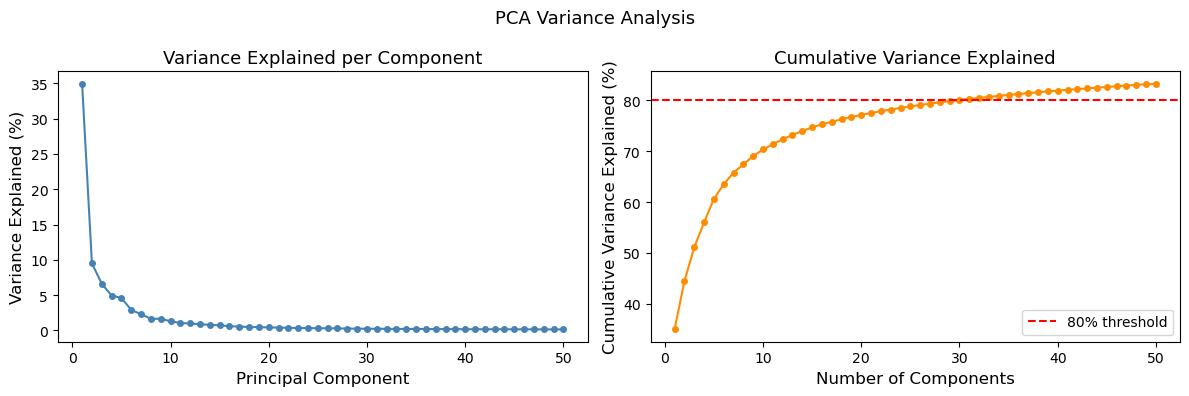

In [11]:
# Plot variance explained by each component (first 50 components)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: variance per component
axes[0].plot(range(1, 51), variance_explained[:50] * 100,
             marker="o", markersize=4, color="steelblue", linewidth=1.5)
axes[0].set_xlabel("Principal Component", fontsize=12)
axes[0].set_ylabel("Variance Explained (%)", fontsize=12)
axes[0].set_title("Variance Explained per Component", fontsize=13)

# Right plot: cumulative variance
cumulative = np.cumsum(variance_explained[:50]) * 100
axes[1].plot(range(1, 51), cumulative,
             marker="o", markersize=4, color="darkorange", linewidth=1.5)
axes[1].axhline(y=80, color="red", linestyle="--", linewidth=1.5, label="80% threshold")
axes[1].set_xlabel("Number of Components", fontsize=12)
axes[1].set_ylabel("Cumulative Variance Explained (%)", fontsize=12)
axes[1].set_title("Cumulative Variance Explained", fontsize=13)
axes[1].legend()

plt.suptitle("PCA Variance Analysis", fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# Find how many components are needed to explain at least 80% of variance
cumulative_full = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = np.argmax(cumulative_full >= 0.80) + 1  # +1 because index starts at 0

print(f"Components needed to explain 80% of variance: {n_components_80}")

Components needed to explain 80% of variance: 30


In [13]:
# Apply PCA with the components that explain 80% of variance
pca = PCA(n_components=n_components_80)
X_pca = pca.fit_transform(X)

pca_columns = [f"PC{i+1}" for i in range(n_components_80)]
X_pca = pd.DataFrame(X_pca, index=X.index, columns=pca_columns)

print("PCA complete.")
print(f"Original shape: {X.shape}  ->  Compressed shape: {X_pca.shape}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

PCA complete.
Original shape: (438, 13653)  ->  Compressed shape: (438, 30)
Total variance explained: 80.0%


## Step 3 - Visualize PCA 
Each dot is one patient — red for Parkinson's, blue for Control.
If the two groups form separate clusters it means the gene expression
differences between PD and Control are real and strong enough to be visible.

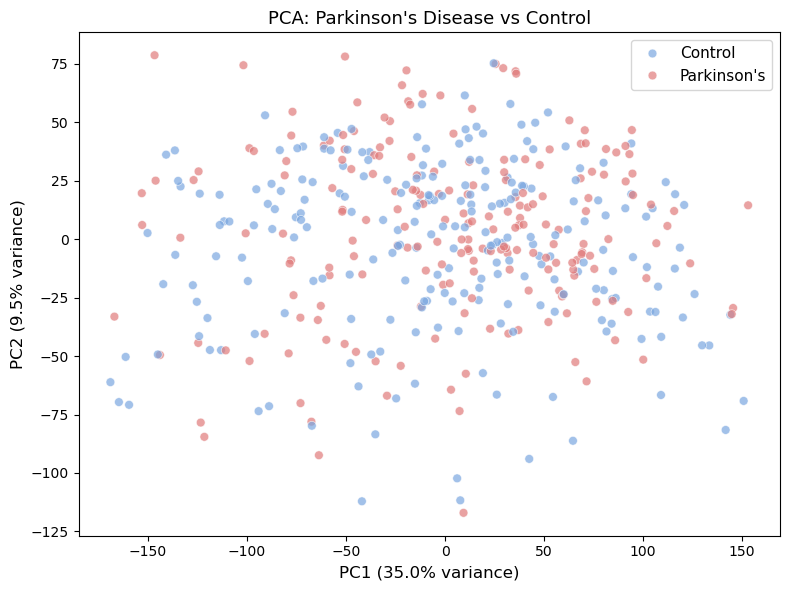

In [15]:
# Create a DataFrame combining PC1, PC2 and the labels for easy plotting
plot_df = pd.DataFrame({
    "PC1": X_pca["PC1"],
    "PC2": X_pca["PC2"],
    "Group": y.map({1: "Parkinson's", 0: "Control"})
})

# 2D scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Group',
                palette={'Parkinson\'s': '#E07B7B', 'Control': '#7BA7E0'},
                alpha=0.7, s=40)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=12)
plt.title("PCA: Parkinson's Disease vs Control", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

The 2D PCA plot shows considerable overlap between IPD and Control 
samples, suggesting that the gene expression differences between 
groups are subtle and not captured by the first two components alone. 
This is consistent with the complex and heterogeneous nature of 
Parkinson's disease. The Random Forest classifier in Notebook 05 
will leverage all 30 principal components to identify patterns 
that are not visible in this 2D projection.

## Step 4 - Save the PCA output

In [16]:
# Attach the labels to the PCA output
X_pca_labeled = X_pca.copy()
X_pca_labeled["label"] = y.values

# Save
X_pca_labeled.to_csv("../data/pca_output.csv.gz", compression="gzip")

print(f"Saved: ../data/pca_output.csv.gz")
print(f"Shape: {X_pca_labeled.shape}  ({X_pca_labeled.shape[0]} samples x {X_pca_labeled.shape[1]-1} components + 1 label)")

Saved: ../data/pca_output.csv.gz
Shape: (438, 31)  (438 samples x 30 components + 1 label)
